# Validating Changes for the Diapause Kernel
Here, we are checking that the updates to the recent diapause kernel are working as expected

In [1]:
%load_ext autoreload
%autoreload 2

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import SpongyMothIPM.meteorology as met
from SpongyMothIPM.config import Config
import SpongyMothIPM.util as util
import SpongyMothIPM.kernels as kernels
import SpongyMothIPM.visualization as viz

## Load Weather Data

In [2]:
df = met.load_daymet_data('../data/mont_st_hilaire/mont_st_hilaire_1980_1991.csv')
low_time = 1
high_time = 13
sample_period = 4
sample_start_time = 1
temps = met.daymet_to_diurnal(df, 
                            low_time, 
                            high_time, 
                            sample_period, 
                            sample_start_time)


config = Config(dtype=torch.float,
                delta_t=sample_period/24)

days = len(temps)//(24//sample_period)
learning_rate = 0.00000001

## Model Setup

In [3]:
diapause = kernels.Diapause(
            config, n_bins_I=100, n_bins_D=100, m_bins_I=20, m_bins_D=20,
            save=True, save_rate=1, mortality=0, sigma_I=0.1, sigma_D=0.1,
            file_path='memory')
diapause.init_pop(1, 0.8, 1.1, 0.2, 1.1)

In [5]:
diapause.incoming.shape

torch.Size([10000, 1])

In [6]:
diapause._pop.shape

torch.Size([10000])

In [7]:
diapause.project_pop([t0]*6)
diapause._pop.shape

torch.Size([10000])

In [9]:
diapause.outgoing.shape

torch.Size([10000, 1])

In [10]:
diapause.init_pop(1, 0.8, 1.1, 0.2, 1.1)
diapause.run_one_step([t0]*6, 0)

TypeError: list indices must be integers or slices, not str

In [ ]:
I_dif = torch.linspace(
                diapause.max_I, 
                diapause.min_I, 
                diapause.n_bins_I)

In [ ]:
I_dif.repeat(20).shape

torch.Size([2000])

In [ ]:
diapause._pop.shape

torch.Size([10000])

In [ ]:
diapause._transform_pop().sum()

tensor(398.3340)

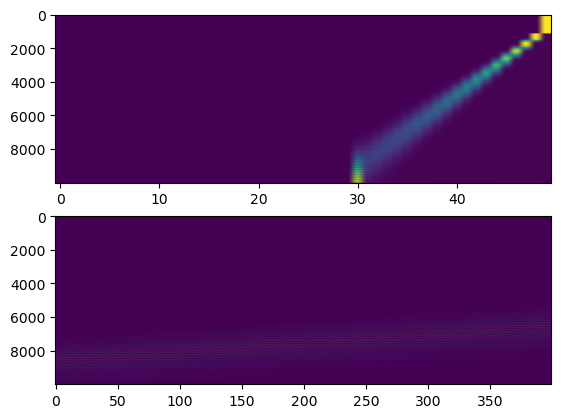

In [ ]:
fig, ax = plt.subplots(nrows=2)
ax[0].imshow(kernel.detach()[:,350:], aspect='auto')
ax[1].imshow(diapause._transform_pop().detach(), aspect='auto')
#ax.imshow(kernel.detach()[:,1500:] < 0.00001, aspect='auto', cmap='Reds')

In [ ]:
torch.sum(kernel, dim=1)

tensor([1., 1., 1.,  ..., 1., 1., 1.], grad_fn=<SumBackward1>)

In [ ]:
diapause.init_pop(1, 0.8, 1.1, 0.2, 1.1)
print(diapause._pop.shape)
diapause.project_pop([t0]*6)
print(diapause._pop.shape)

torch.Size([10000])
torch.Size([10000])


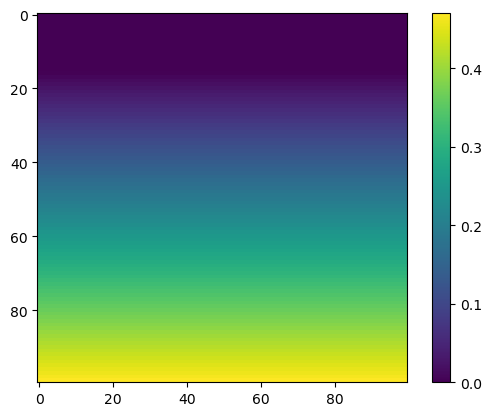

In [ ]:
fig, ax = plt.subplots()
m = ax.imshow(test.reshape(100, 100)*6)
fig.colorbar(m)